In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

In [2]:
df = pd.read_csv("cleaned_aqi.csv")

In [3]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14313 entries, 0 to 14312
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   City              14313 non-null  object 
 1   Date              14313 non-null  object 
 2   PM2.5             14313 non-null  float64
 3   PM10              14313 non-null  float64
 4   NO                14313 non-null  float64
 5   NO2               14313 non-null  float64
 6   NOx               14313 non-null  float64
 7   NH3               14313 non-null  float64
 8   CO                14313 non-null  float64
 9   SO2               14313 non-null  float64
 10  O3                14313 non-null  float64
 11  Benzene           14313 non-null  float64
 12  Toluene           14313 non-null  float64
 13  Xylene            14313 non-null  float64
 14  AQI               14313 non-null  float64
 15  AQI_Bucket        14313 non-null  object 
 16  Year              14313 non-null  int64 

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,Xylene,AQI,Year,Month,Day,Quarter,Pollution_Index,Previous_AQI,Rolling_7Day_AQI,AQI_Change
count,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,...,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,14313.000000,14303.000000,14313.000000,14303.000000
mean,72.873727,142.692707,29.161747,29.638116,40.986656,24.994065,0.994425,26.769436,34.269769,2.667219,...,3.469834,159.541186,2017.754000,6.327534,15.737581,2.439740,74.283290,159.600294,159.681397,-0.052716
std,74.963135,105.178506,36.691909,23.526175,39.707563,17.831186,1.526216,49.340711,22.971422,4.499343,...,6.913131,110.698835,1.507407,3.443066,8.803648,1.114161,52.695235,110.711410,103.721728,42.713863
min,2.000000,7.120000,0.090000,0.040000,0.000000,0.060000,0.000000,0.210000,0.020000,0.000000,...,0.000000,20.000000,2015.000000,1.000000,1.000000,1.000000,7.254000,20.000000,31.285714,-649.000000
25%,25.500000,63.230000,6.590000,11.870000,16.420000,9.580000,0.390000,6.240000,17.240000,0.180000,...,0.120000,73.000000,2017.000000,3.000000,8.000000,1.000000,42.276000,73.000000,78.428571,-10.000000
50%,49.190000,112.780000,13.560000,22.840000,26.800000,18.940000,0.750000,10.270000,28.770000,1.460000,...,0.910000,120.000000,2018.000000,6.000000,16.000000,2.000000,57.890000,120.000000,122.428571,0.000000
75%,90.710000,158.460000,31.930000,40.390000,50.510000,39.690000,1.230000,18.720000,43.370000,3.500000,...,4.100000,212.000000,2019.000000,9.000000,23.000000,3.000000,92.242000,212.000000,212.428571,12.000000
max,949.990000,917.080000,287.140000,362.210000,467.630000,166.700000,39.800000,193.860000,257.730000,142.000000,...,170.370000,891.000000,2020.000000,12.000000,31.000000,4.000000,949.116000,891.000000,676.000000,621.000000


In [4]:
X = df[[
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene'
]]

y = df['AQI']

In [5]:
print(X.isnull().sum())

print(y.isnull().sum())

PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64
0


In [6]:
X = X.fillna(X.median(numeric_only=True))

y = y.fillna(y.median())

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [9]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, pred_lr))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_lr)))

print("R2 Score :", r2_score(y_test, pred_lr))

Linear Regression
MAE : 28.558212068660733
RMSE : 44.17164928578294
R2 Score : 0.8348548827761313


In [10]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [11]:
print("Decision Tree")

print("MAE :", mean_absolute_error(y_test, pred_dt))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_dt)))

print("R2 Score :", r2_score(y_test, pred_dt))

Decision Tree
MAE : 22.62623122598673
RMSE : 42.2815754280468
R2 Score : 0.8486854018339554


In [12]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [13]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, pred_rf))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_rf)))

print("R2 Score :", r2_score(y_test, pred_rf))

Random Forest
MAE : 16.085399156258614
RMSE : 29.71700686221909
R2 Score : 0.9252538830351288


In [14]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_dt),
        mean_absolute_error(y_test,pred_rf)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_dt)),
        np.sqrt(mean_squared_error(y_test,pred_rf))
    ],

    "R2 Score":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_dt),
        r2_score(y_test,pred_rf)
    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,28.558212,44.171649,0.834855
1,Decision Tree,22.626231,42.281575,0.848685
2,Random Forest,16.085399,29.717007,0.925254


In [15]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,PM2.5,0.872003
1,PM10,0.041587
6,CO,0.015310
8,O3,0.011627
4,NOx,0.010741
7,SO2,0.008048
3,NO2,0.008026
2,NO,0.007260
10,Toluene,0.007202
5,NH3,0.007035


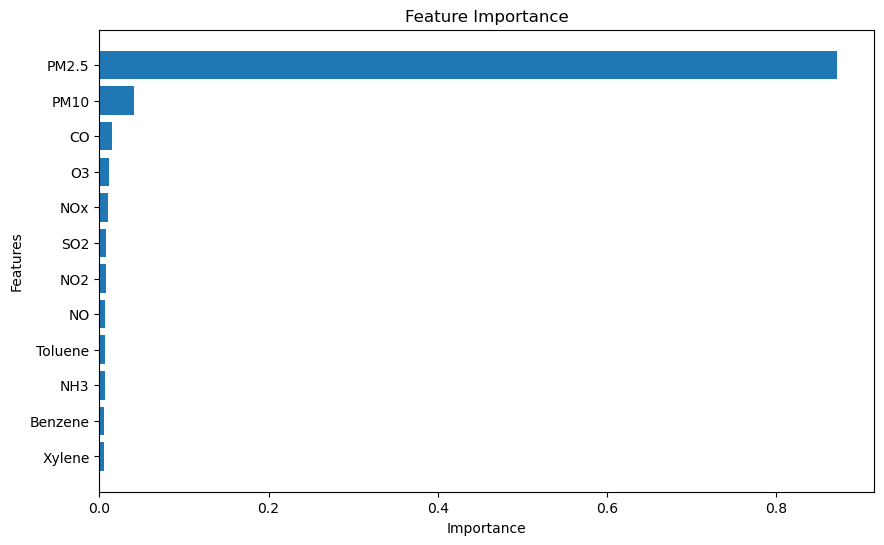

In [16]:
importance = importance.sort_values(
    by="Importance"
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

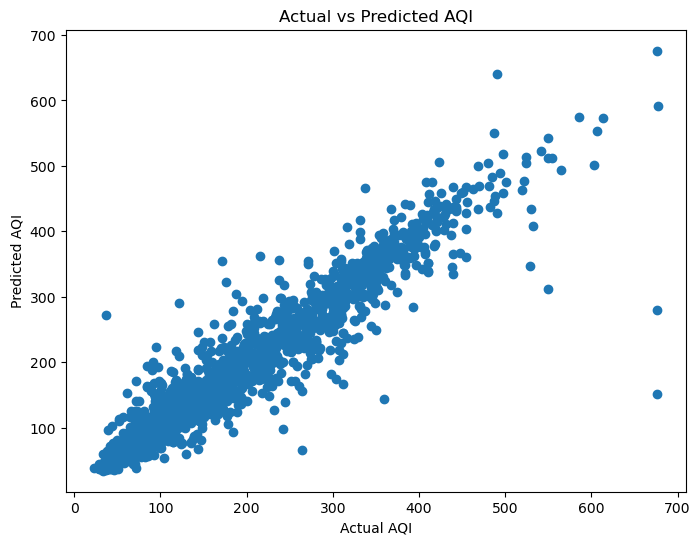

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf)

plt.xlabel("Actual AQI")

plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.show()

In [18]:
sample = [[
80,
150,
25,
40,
65,
30,
1.2,
18,
50,
2,
3,
1
]]

prediction = rf.predict(sample)

print("Predicted AQI :", prediction[0])

Predicted AQI : 188.165


C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [19]:
!pip install joblib

In [20]:
import joblib
joblib.dump(
    rf,
    "aqi_prediction_model.pkl"
)

['aqi_prediction_model.pkl']

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

In [22]:
!pip install xgboost

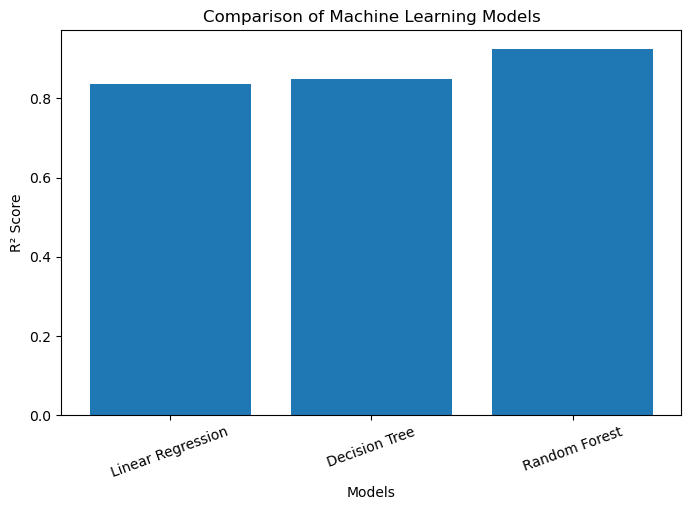

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("Comparison of Machine Learning Models")

plt.xlabel("Models")

plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

In [26]:
%whos

Variable                    Type                         Data/Info
------------------------------------------------------------------
DecisionTreeRegressor       ABCMeta                      <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
GradientBoostingRegressor   ABCMeta                      <class 'sklearn.ensemble.<...>adientBoostingRegressor'>
LinearRegression            ABCMeta                      <class 'sklearn.linear_mo<...>._base.LinearRegression'>
NamespaceMagics             MetaHasTraits                <class 'IPython.core.magi<...>mespace.NamespaceMagics'>
RandomForestRegressor       ABCMeta                      <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
X                           DataFrame                    Shape: (14313, 12)
X_test                      DataFrame                    Shape: (2863, 12)
X_train                     DataFrame                    Shape: (11450, 12)
collections                 module                       <module 'collecti

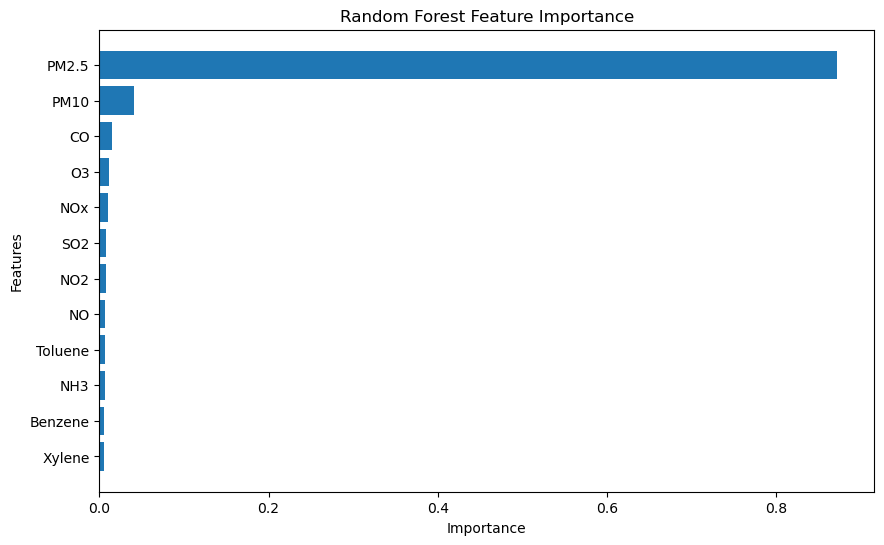

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

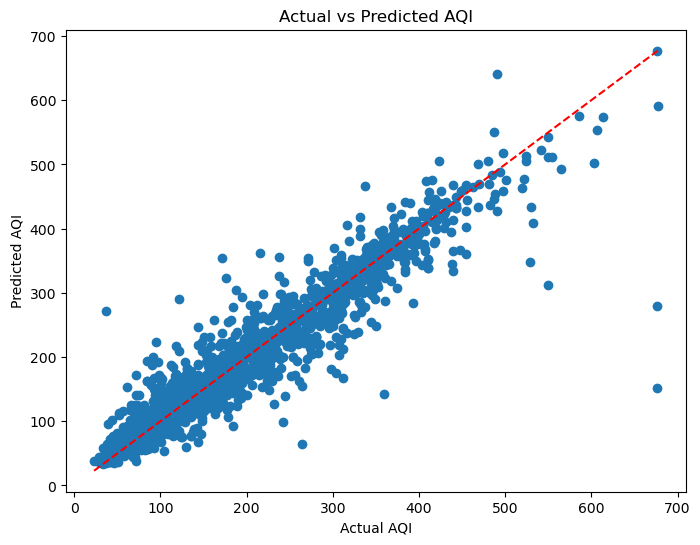

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()